# Heart Rate Estimation from NIR Facial Videos

This notebook builds a simple neural network that predicts heart rate (in BPM) from Near-Infrared facial video clips.

Dataset used: **MR-NIRP-D**

## Steps:
1. Unzip and explore the `.pgm` frames
2. Load and process `pulseOx.mat` to get ground truth BPM
3. Extract face ROI from each frame
4. Build a dataset of video clips + BPM labels
5. Train a 3D CNN + Transformer model
6. Evaluate with MAE, RMSE, Pearson r

## Step 1 — Install & Import Libraries

In [1]:
import os
import glob
import numpy as np
import cv2
import math
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, sosfiltfilt, find_peaks, welch
from scipy.stats import pearsonr
from scipy.io import loadmat

print('All imports done!')
print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

All imports done!
PyTorch version: 2.12.0+cpu
GPU available: False
Using device: cpu


## Step 2 — Path & Settings

In [32]:
# ---- UPDATE THESE TWO PATHS ----

NIR_ZIP    = r'D:\Data Science\UST\Heart Rate\data\raw\Subject1\subject1_driving_large_motion_975\NIR.zip'
PULSE_MAT  = r'D:\Data Science\UST\Heart Rate\data\raw\Subject1\subject1_driving_large_motion_975\PulseOx\pulseOx.mat'
FRAMES_DIR = r'D:\Data Science\UST\Heart Rate\data\raw\Subject1\subject1_driving_large_motion_975\NIR_frames'
PROCESSED_DIR = r'D:\Data Science\UST\Heart Rate\data\processed'

# --------------------------------

# model / training settings
CLIP_LEN   = 150    # 5 seconds at 30 fps
STRIDE     = 30     # smaller stride = more clips from one session
ROI_SIZE   = 64
BATCH_SIZE = 4      # small because we have one session only
EPOCHS     = 10
LR         = 1e-3
VIDEO_FPS  = 30.0

# NEW: model output directory
OUTPUT_DIR = r'D:\Data Science\UST\Heart Rate\outputs'

# save model path
MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_model.pth')

print('Paths set!')

Paths set!


## Step 3 — Unzip NIR Frames
Extract all `.pgm` files from `NIR.zip` into a local folder.

In [10]:
print('Extracting NIR.zip...')
with zipfile.ZipFile(NIR_ZIP, 'r') as z:
    pgm_files_in_zip = [f for f in z.namelist() if f.lower().endswith('.pgm')]
    print(f'Found {len(pgm_files_in_zip)} PGM files in zip')
    z.extractall(FRAMES_DIR)

# collect all extracted PGM files and sort them
all_frames = sorted(glob.glob(os.path.join(FRAMES_DIR, '**', '*.pgm'), recursive=True))
print(f'Total PGM frames extracted: {len(all_frames)}')
print(f'First frame: {all_frames[0]}')
print(f'Last frame : {all_frames[-1]}')

Extracting NIR.zip...
Found 10122 PGM files in zip
Total PGM frames extracted: 10122
First frame: D:\Data Science\UST\Heart Rate\data\raw\Subject1\subject1_driving_large_motion_975\NIR_frames\NIR\Frame00000.pgm
Last frame : D:\Data Science\UST\Heart Rate\data\raw\Subject1\subject1_driving_large_motion_975\NIR_frames\NIR\Frame10121.pgm


## Step 4 — Explore the PGM Frames

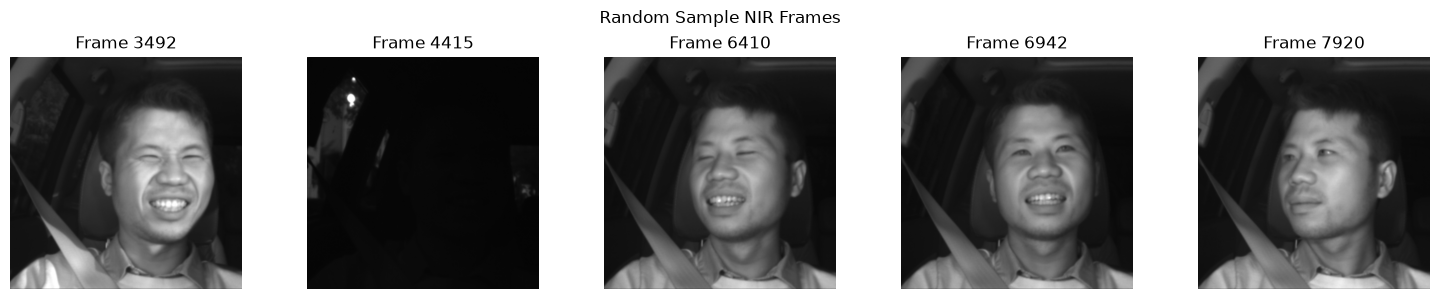

Frame resolution : 640 x 640 pixels
Pixel range      : 0 – 202
Estimated duration: 337.4 seconds (10122 frames @ 30.0fps)


In [11]:
# collect all PGM files directly from directory
all_frames = sorted(glob.glob(os.path.join(FRAMES_DIR, '**', '*.pgm'), recursive=True))

# pick 5 random frame indices
sample_indices = sorted(
    random.sample(range(len(all_frames)), 5)
)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, idx in enumerate(sample_indices):
    img = cv2.imread(all_frames[idx], cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Frame {idx}")
    axes[i].axis("off")

plt.suptitle("Random Sample NIR Frames")
plt.tight_layout()
plt.show()

# print basic image info
sample = cv2.imread(all_frames[0], cv2.IMREAD_GRAYSCALE)

print(f"Frame resolution : {sample.shape[1]} x {sample.shape[0]} pixels")
print(f"Pixel range      : {sample.min()} – {sample.max()}")

total_secs = len(all_frames) / VIDEO_FPS
print(f"Estimated duration: {total_secs:.1f} seconds ({len(all_frames)} frames @ {VIDEO_FPS}fps)")

## Step 5 — Load & Process `pulseOx.mat`

The `pulseOx.mat` file contains the reference heart rate signal recorded by a pulse oximeter worn by the subject.
We need to:
1. Inspect what keys are inside the `.mat` file
2. Extract the raw PPG signal and its sampling rate
3. Derive BPM values using bandpass filtering + peak detection

In [ ]:
# load the mat file and see what's inside
mat = loadmat(PULSE_MAT)

print('Keys in pulseOx.mat:')
for k, v in mat.items():
    if not k.startswith('_'):   # skip matlab metadata keys
        print(f'  {k:20s} → shape: {np.array(v).shape}, dtype: {np.array(v).dtype}')

Keys in pulseOx.mat:
  pulseOxRecord        → shape: (1, 9740), dtype: int64
  pulseOxTime          → shape: (1, 9740), dtype: float64
  numPulseSample       → shape: (1, 1), dtype: int64


Using signal key: "pulseOxRecord"
Signal length : 9740 samples


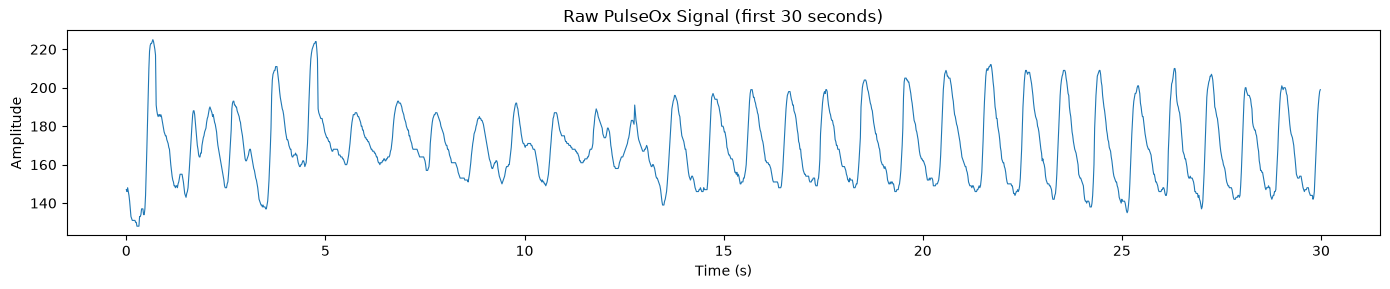

Signal range: 128.00 to 234.00
Sampling rate : 60.0 Hz
Duration      : 162.3 seconds


In [13]:
# try to auto-detect the signal key
signal_key = None
for candidate in ['pulseOxRecord', 'pulseOxTime', 'numPulseSample']:
    if candidate in mat:
        signal_key = candidate
        break

# if none found, just grab the first non-metadata array
if signal_key is None:
    for k, v in mat.items():
        if not k.startswith('_') and isinstance(v, np.ndarray):
            signal_key = k
            break

print(f'Using signal key: "{signal_key}"')
raw_signal = mat[signal_key].flatten().astype(np.float64)

# try to get sampling rate
pulse_fs = 60.0   # pulseOx in MR-NIRP-D is typically 60 Hz — update if different
for fs_key in ['fs', 'Fs', 'sampleRate', 'sample_rate']:
    if fs_key in mat:
        pulse_fs = float(mat[fs_key].flatten()[0])
        break

print(f'Signal length : {len(raw_signal)} samples')# plot the raw pulse oximeter signal
t_ref = np.arange(len(raw_signal)) / pulse_fs

plt.figure(figsize=(14, 3))
plt.plot(t_ref[:int(pulse_fs*30)], raw_signal[:int(pulse_fs*30)], linewidth=0.8)
plt.title('Raw PulseOx Signal (first 30 seconds)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

print(f'Signal range: {raw_signal.min():.2f} to {raw_signal.max():.2f}')
print(f'Sampling rate : {pulse_fs} Hz')
print(f'Duration      : {len(raw_signal)/pulse_fs:.1f} seconds')

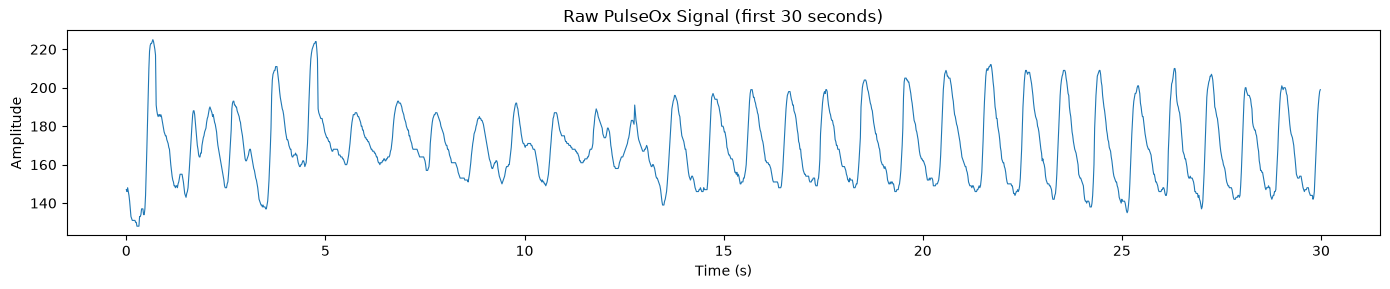

Signal range: 128.00 to 234.00


In [14]:
# plot the raw pulse oximeter signal
t_ref = np.arange(len(raw_signal)) / pulse_fs

plt.figure(figsize=(14, 3))
plt.plot(t_ref[:int(pulse_fs*30)], raw_signal[:int(pulse_fs*30)], linewidth=0.8)
plt.title('Raw PulseOx Signal (first 30 seconds)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

print(f'Signal range: {raw_signal.min():.2f} to {raw_signal.max():.2f}')

## Step 6 — BPM Derivation Functions

Convert the raw pulseOx signal into BPM for any given time window.

In [15]:
def bandpass_filter(signal, fs, lowcut=0.7, highcut=3.5, order=2):
    """Keep only 0.7–3.5 Hz (= 42–210 BPM). Uses SOS form for stability."""
    nyq = 0.5 * fs
    sos = butter(order, [lowcut / nyq, highcut / nyq], btype='band', output='sos')
    return sosfiltfilt(sos, signal)


def derive_bpm(signal, fs):
    """Compute BPM from a window of reference signal."""
    filtered = bandpass_filter(signal, fs)
    filtered = (filtered - filtered.mean()) / (filtered.std() + 1e-8)

    # peak detection
    peaks, _ = find_peaks(filtered, distance=int(fs * 0.3))
    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs
        return float(np.clip(60.0 / ibi.mean(), 40, 210))

    # fallback: dominant frequency via Welch PSD
    nperseg = min(int(fs * 4), len(filtered))
    freqs, psd = welch(filtered, fs=fs, nperseg=nperseg)
    mask = (freqs >= 0.7) & (freqs <= 3.5)
    if mask.sum() == 0:
        return 70.0
    return float(np.clip(freqs[mask][np.argmax(psd[mask])] * 60.0, 40, 210))


def get_bpm_for_clip(clip_start_frame, clip_len, total_frames, ref_signal, ref_fs):
    """
    Given a clip's start frame index, extract the corresponding
    window of the reference signal and return its BPM.
    Assumes video and reference signal have the same duration.
    """
    ref_len   = len(ref_signal)
    ref_start = int(clip_start_frame / total_frames * ref_len)
    ref_end   = int((clip_start_frame + clip_len) / total_frames * ref_len)
    ref_end   = min(ref_end, ref_len)
    window    = ref_signal[ref_start:ref_end]
    if len(window) < 10:
        return 70.0
    return derive_bpm(window, ref_fs)


print('BPM functions defined!')

BPM functions defined!


BPM for first clip: 121.3


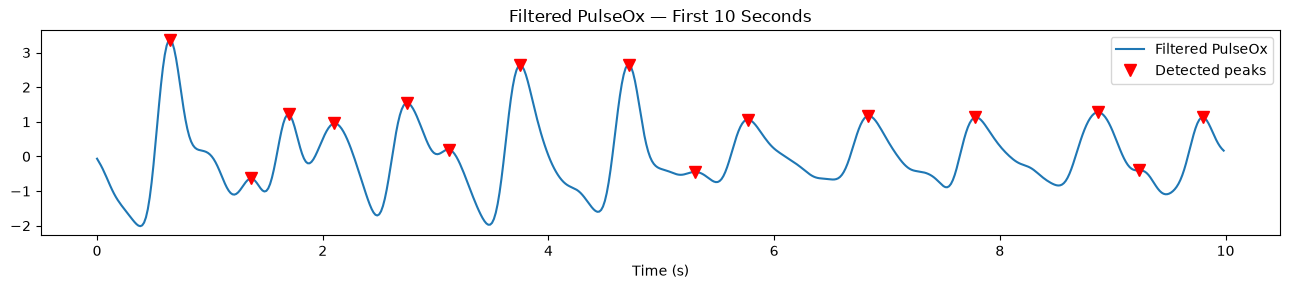

Mean IBI : 0.654 s  →  91.8 BPM


In [16]:
# test: compute BPM for the first 5 seconds of the reference signal
test_bpm = get_bpm_for_clip(0, CLIP_LEN, len(all_frames), raw_signal, pulse_fs)
print(f'BPM for first clip: {test_bpm:.1f}')

# visualise the filtered version of the first 10 seconds
window_10s = raw_signal[:int(pulse_fs * 10)]
filtered_10s = bandpass_filter(window_10s, pulse_fs)
filtered_10s = (filtered_10s - filtered_10s.mean()) / (filtered_10s.std() + 1e-8)
peaks, _ = find_peaks(filtered_10s, distance=int(pulse_fs * 0.3))

t10 = np.arange(len(window_10s)) / pulse_fs
plt.figure(figsize=(13, 3))
plt.plot(t10, filtered_10s, label='Filtered PulseOx')
plt.plot(t10[peaks], filtered_10s[peaks], 'rv', ms=8, label='Detected peaks')
plt.title('Filtered PulseOx — First 10 Seconds')
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()

if len(peaks) >= 2:
    mean_ibi = np.diff(peaks).mean() / pulse_fs
    print(f'Mean IBI : {mean_ibi:.3f} s  →  {60/mean_ibi:.1f} BPM')

## Step 7 — Face ROI Extraction

Detect the face in each PGM frame and crop it to a fixed 64×64 patch.
Uses OpenCV's Haar cascade — works on greyscale NIR images.

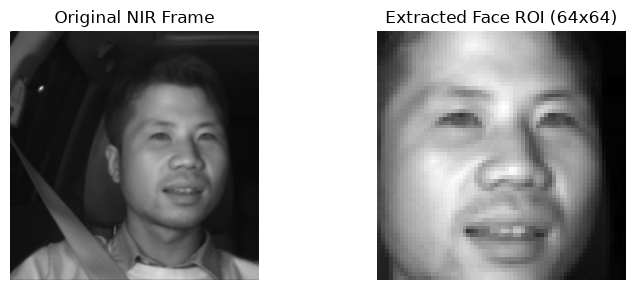

Face ROI extraction working!


In [18]:
class FaceROIExtractor:
    def __init__(self, roi_size=64):
        self.roi_size = roi_size
        cascade_path  = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        self.detector = cv2.CascadeClassifier(cascade_path)
        self._last_bbox = None

    def extract(self, gray_frame):
        faces = self.detector.detectMultiScale(
            gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
        )
        if len(faces) > 0:
            areas = [w * h for (x, y, w, h) in faces]
            x, y, w, h = faces[np.argmax(areas)]
            self._last_bbox = (x, y, w, h)
        elif self._last_bbox is not None:
            x, y, w, h = self._last_bbox   # reuse last detection
        else:
            H, W = gray_frame.shape
            m = min(H, W) // 4
            x, y, w, h = m, m, W - 2*m, H - 2*m   # centre crop fallback

        roi = gray_frame[y:y+h, x:x+w]
        roi = cv2.resize(roi, (self.roi_size, self.roi_size))
        return roi.astype(np.float32) / 255.0


# test on a sample frame
extractor  = FaceROIExtractor(ROI_SIZE)
test_frame = cv2.imread(all_frames[len(all_frames)//4], cv2.IMREAD_GRAYSCALE)
test_roi   = extractor.extract(test_frame)

# SAVE OUTPUTS
orig_path = os.path.join(PROCESSED_DIR, "sample_original.png")
roi_path  = os.path.join(PROCESSED_DIR, "sample_roi.png")

cv2.imwrite(orig_path, test_frame)
cv2.imwrite(roi_path, (test_roi * 255).astype(np.uint8))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.imshow(test_frame, cmap='gray')
ax1.set_title('Original NIR Frame')
ax1.axis('off')
ax2.imshow(test_roi, cmap='gray')
ax2.set_title(f'Extracted Face ROI ({ROI_SIZE}x{ROI_SIZE})')
ax2.axis('off')
plt.tight_layout()
plt.show()
print('Face ROI extraction working!')

## Step 8 — Build the Dataset

Since we only have **one session**, we create many overlapping clips using a sliding window.
Each clip is 150 frames (5s) with a stride of 30 frames.

Train/Val/Test split is done by clip position (not random) to avoid data leakage.

In [19]:
class NIRDataset(Dataset):
    def __init__(self, frame_paths, ref_signal, ref_fs, clip_len, stride,
                 roi_size, start_idx, end_idx):
        """
        frame_paths : sorted list of all PGM file paths
        ref_signal  : raw pulseOx signal array
        ref_fs      : sampling rate of ref_signal
        start_idx   : first frame index to use (for train/val/test split)
        end_idx     : last frame index to use
        """
        self.frame_paths = frame_paths
        self.ref_signal  = ref_signal
        self.ref_fs      = ref_fs
        self.clip_len    = clip_len
        self.roi_size    = roi_size
        self.total_frames = len(frame_paths)
        self.extractor   = FaceROIExtractor(roi_size)

        # build list of valid clip start positions within [start_idx, end_idx]
        self.starts = []
        for s in range(start_idx, end_idx - clip_len + 1, stride):
            self.starts.append(s)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        start = self.starts[idx]

        # load CLIP_LEN frames and extract face ROI from each
        rois = []
        for i in range(self.clip_len):
            fp  = self.frame_paths[start + i]
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                img = np.zeros((self.roi_size, self.roi_size), dtype=np.uint8)
            rois.append(self.extractor.extract(img))

        clip   = np.stack(rois, axis=0)              # (T, H, W)
        tensor = torch.from_numpy(clip).unsqueeze(0) # (1, T, H, W)

        bpm = get_bpm_for_clip(start, self.clip_len,
                               self.total_frames, self.ref_signal, self.ref_fs)
        return tensor, torch.tensor(bpm, dtype=torch.float32)


print('Dataset class defined!')

Dataset class defined!


In [20]:
# train / val / test split by frame position
# avoids leakage: test frames come AFTER train frames in time
n = len(all_frames)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

print(f'Total frames  : {n}')
print(f'Train frames  : 0 – {train_end}  ({train_end} frames)')
print(f'Val frames    : {train_end} – {val_end}  ({val_end - train_end} frames)')
print(f'Test frames   : {val_end} – {n}  ({n - val_end} frames)')

train_ds = NIRDataset(all_frames, raw_signal, pulse_fs, CLIP_LEN, STRIDE,
                      ROI_SIZE, start_idx=0,         end_idx=train_end)
val_ds   = NIRDataset(all_frames, raw_signal, pulse_fs, CLIP_LEN, STRIDE,
                      ROI_SIZE, start_idx=train_end, end_idx=val_end)
test_ds  = NIRDataset(all_frames, raw_signal, pulse_fs, CLIP_LEN, STRIDE,
                      ROI_SIZE, start_idx=val_end,   end_idx=n)

print(f'\nTrain clips : {len(train_ds)}')
print(f'Val clips   : {len(val_ds)}')
print(f'Test clips  : {len(test_ds)}')

Total frames  : 10122
Train frames  : 0 – 7085  (7085 frames)
Val frames    : 7085 – 8603  (1518 frames)
Test frames   : 8603 – 10122  (1519 frames)

Train clips : 232
Val clips   : 46
Test clips  : 46


Clip tensor shape : torch.Size([1, 150, 64, 64])
BPM label         : 121.3


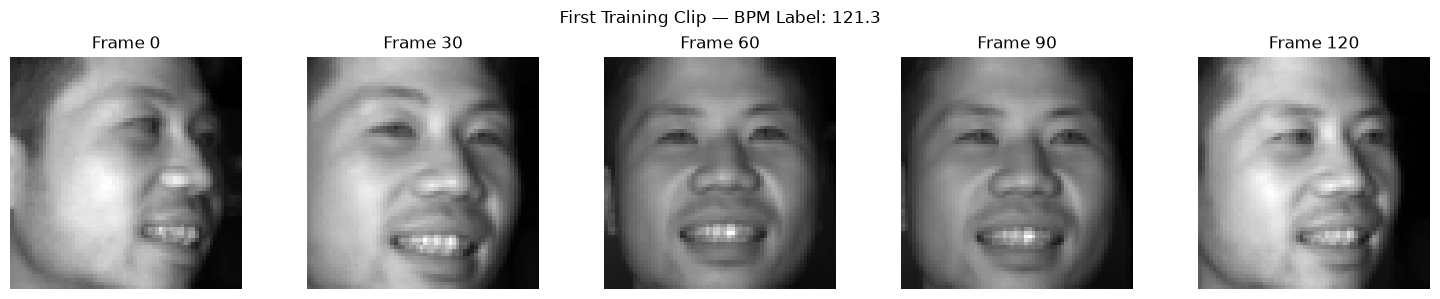

In [21]:
# check one sample
sample_clip, sample_bpm = train_ds[0]
print(f'Clip tensor shape : {sample_clip.shape}')   # (1, 150, 64, 64)
print(f'BPM label         : {sample_bpm.item():.1f}')

# show a few frames from the first clip
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, t in enumerate([0, 30, 60, 90, 120]):
    axes[i].imshow(sample_clip[0, t].numpy(), cmap='gray')
    axes[i].set_title(f'Frame {t}')
    axes[i].axis('off')
plt.suptitle(f'First Training Clip — BPM Label: {sample_bpm.item():.1f}')
plt.tight_layout()
plt.show()

Computing BPM labels for all training clips


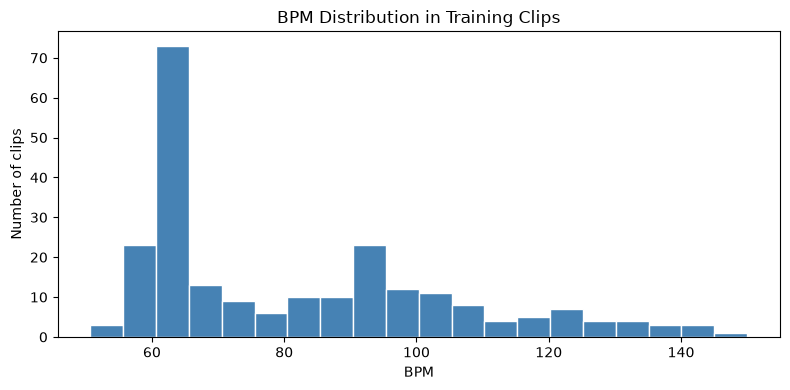

Mean : 82.2 BPM
Std  : 23.3 BPM
Min  : 50.7  Max : 150.0


In [32]:
# check the BPM distribution across all training clips
print('Computing BPM labels for all training clips')
bpm_labels = [train_ds[i][1].item() for i in range(len(train_ds))]

plt.figure(figsize=(8, 4))
plt.hist(bpm_labels, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('BPM')
plt.ylabel('Number of clips')
plt.title('BPM Distribution in Training Clips')
plt.tight_layout()
plt.show()

print(f'Mean : {np.mean(bpm_labels):.1f} BPM')
print(f'Std  : {np.std(bpm_labels):.1f} BPM')
print(f'Min  : {np.min(bpm_labels):.1f}  Max : {np.max(bpm_labels):.1f}')

In [22]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# num_workers=0 is safer on Windows
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 58
Val batches   : 12


## Step 9 — Model

**3D CNN → Transformer → BPM**

- 3D CNN captures how the face pixel values change over time (micro blood flow changes)
- Transformer looks for repeating periodic patterns across the 150 frames
- Output head predicts a single BPM number

In [23]:
class ConvBnRelu3D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=(1,3,3), padding=(0,1,1)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel, padding=padding, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class HREstimator(nn.Module):
    def __init__(self, base_ch=32, n_heads=4, n_layers=2,
                 bpm_min=40.0, bpm_max=210.0):
        super().__init__()
        d = base_ch * 4

        # 3D CNN stem
        self.cnn = nn.Sequential(
            ConvBnRelu3D(1,         base_ch,   kernel=(1,5,5), padding=(0,2,2)),
            nn.MaxPool3d((1,2,2)),
            ConvBnRelu3D(base_ch,   base_ch*2),
            nn.MaxPool3d((1,2,2)),
            ConvBnRelu3D(base_ch*2, base_ch*4),
            nn.MaxPool3d((1,2,2)),
        )
        self.spatial_pool = nn.AdaptiveAvgPool3d((None, 1, 1))

        # temporal transformer
        self.pe  = PositionalEncoding(d)
        enc      = nn.TransformerEncoderLayer(
            d_model=d, nhead=n_heads, dim_feedforward=256,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)

        # BPM regression head
        self.head = nn.Sequential(
            nn.Linear(d, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        self.bpm_min = bpm_min
        self.bpm_max = bpm_max

    def forward(self, x):
        x = self.cnn(x)                     # (B, C, T, h, w)
        x = self.spatial_pool(x)            # (B, C, T, 1, 1)
        x = x.squeeze(-1).squeeze(-1)       # (B, C, T)
        x = x.permute(0, 2, 1)             # (B, T, C)
        x = self.pe(x)
        x = self.transformer(x)             # (B, T, C)
        x = x.mean(dim=1)                   # (B, C)
        x = self.head(x).squeeze(-1)        # (B,)
        return torch.sigmoid(x) * (self.bpm_max - self.bpm_min) + self.bpm_min


model = HREstimator().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready! Parameters: {n_params:,}')

# sanity check forward pass
dummy = torch.randn(2, 1, CLIP_LEN, ROI_SIZE, ROI_SIZE).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'Input : {dummy.shape}  →  Output : {out.shape}  →  {out.cpu().numpy().round(1)} BPM')

C:\Users\roy_q\AppData\Local\Temp\ipykernel_8648\1882763340.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)


Model ready! Parameters: 366,689
Input : torch.Size([2, 1, 150, 64, 64])  →  Output : torch.Size([2])  →  [145.  144.1] BPM


## Step 10 — Loss, Optimizer, Scheduler

In [24]:
# Huber loss — less sensitive to outlier BPM labels than MSE
criterion = nn.HuberLoss(delta=5.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print('Loss      : HuberLoss (delta=5 BPM)')
print('Optimizer : AdamW  lr=1e-3  wd=1e-4')
print('Scheduler : CosineAnnealingLR')

Loss      : HuberLoss (delta=5 BPM)
Optimizer : AdamW  lr=1e-3  wd=1e-4
Scheduler : CosineAnnealingLR


## Step 11 — Training Loop

In [25]:
def run_epoch(model, loader, optimizer, criterion, device, training=True):
    model.train() if training else model.eval()
    losses, preds_all, targets_all = [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for clips, bpms in loader:
            clips = clips.to(device)
            bpms  = bpms.to(device)
            preds = model(clips)
            loss  = criterion(preds, bpms)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            losses.append(loss.item())
            preds_all.extend(preds.detach().cpu().numpy())
            targets_all.extend(bpms.cpu().numpy())

    mae = np.mean(np.abs(np.array(preds_all) - np.array(targets_all)))
    return np.mean(losses), mae


print('Training function ready!')

Training function ready!


In [40]:
train_losses, val_losses = [], []
train_maes,   val_maes   = [], []
best_val_mae  = float('inf')
best_epoch    = 0
patience_ctr  = 0
PATIENCE      = 10

print(f'Training for up to {EPOCHS} epochs (early stop patience={PATIENCE})\n')
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Val Loss":>9}  {"Train MAE":>10}  {"Val MAE":>8}')
print('-' * 57)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_mae = run_epoch(model, train_loader, optimizer, criterion, device, training=True)
    vl_loss, vl_mae = run_epoch(model, val_loader,   optimizer, criterion, device, training=False)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_maes.append(tr_mae)
    val_maes.append(vl_mae)

    print(f'{epoch:>6}  {tr_loss:>10.4f}  {vl_loss:>9.4f}  {tr_mae:>10.2f}  {vl_mae:>8.2f}')

    if vl_mae < best_val_mae:
        best_val_mae = vl_mae
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'         ✓ new best saved  (val MAE = {best_val_mae:.2f} BPM)')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping — no improvement for {PATIENCE} epochs')
            break

print(f'\nDone! Best val MAE = {best_val_mae:.2f} BPM at epoch {best_epoch}')

Training for up to 10 epochs (early stop patience=10)

 Epoch  Train Loss   Val Loss   Train MAE   Val MAE
---------------------------------------------------------
     1     77.0545    60.8579       17.68     14.89
         ✓ new best saved  (val MAE = 14.89 BPM)
     2     76.7729    55.9335       17.71     13.87
         ✓ new best saved  (val MAE = 13.87 BPM)
     3     75.3236    64.9810       17.44     15.68
     4     82.8958    62.7408       18.88     15.31
     5     80.0058    76.6370       18.45     17.92
     6     77.4588    70.0293       17.80     16.65
     7     76.8796    67.1669       17.71     16.11
     8     79.3619    69.9533       18.24     16.64


KeyboardInterrupt: 

## Step 12 — Training Curves

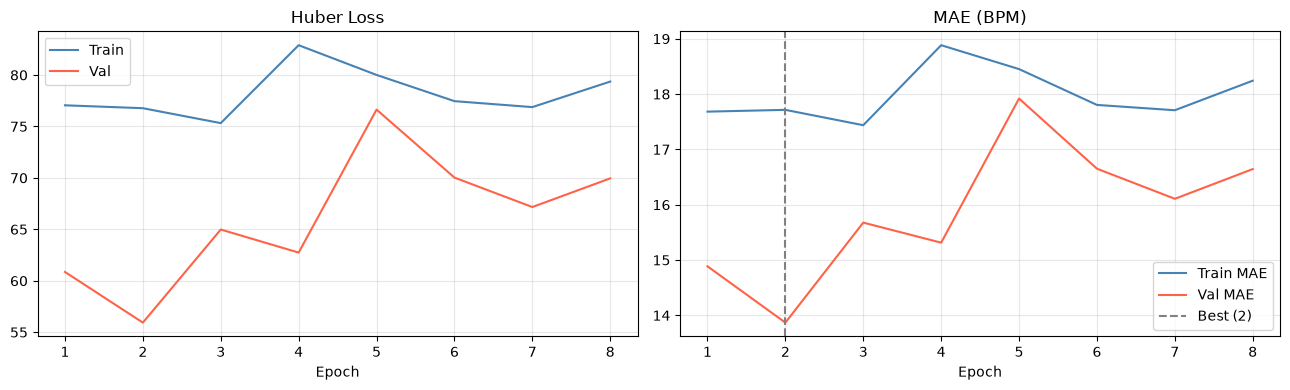

In [41]:
ep = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ep, train_losses, label='Train', color='steelblue')
ax1.plot(ep, val_losses,   label='Val',   color='tomato')
ax1.set_title('Huber Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, train_maes, label='Train MAE', color='steelblue')
ax2.plot(ep, val_maes,   label='Val MAE',   color='tomato')
ax2.axvline(best_epoch, color='gray', linestyle='--', label=f'Best ({best_epoch})')
ax2.set_title('MAE (BPM)')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "training_plot.png")
plt.savefig(plot_path, dpi=150)
plt.show()

## Step 13 — Evaluation on Test Set

In [42]:
# load best checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for clips, bpms in test_loader:
        preds = model(clips.to(device)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(bpms.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

mae     = np.mean(np.abs(all_preds - all_targets))
rmse    = np.sqrt(np.mean((all_preds - all_targets)**2))
pearson = pearsonr(all_preds, all_targets)[0] if len(all_preds) > 1 else float('nan')

print('================================')
print('       TEST SET RESULTS')
print('================================')
print(f'  MAE        : {mae:.2f} BPM')
print(f'  RMSE       : {rmse:.2f} BPM')
print(f'  Pearson r  : {pearson:.4f}')
print('================================')

       TEST SET RESULTS
  MAE        : 17.40 BPM
  RMSE       : 22.85 BPM
  Pearson r  : 0.1534


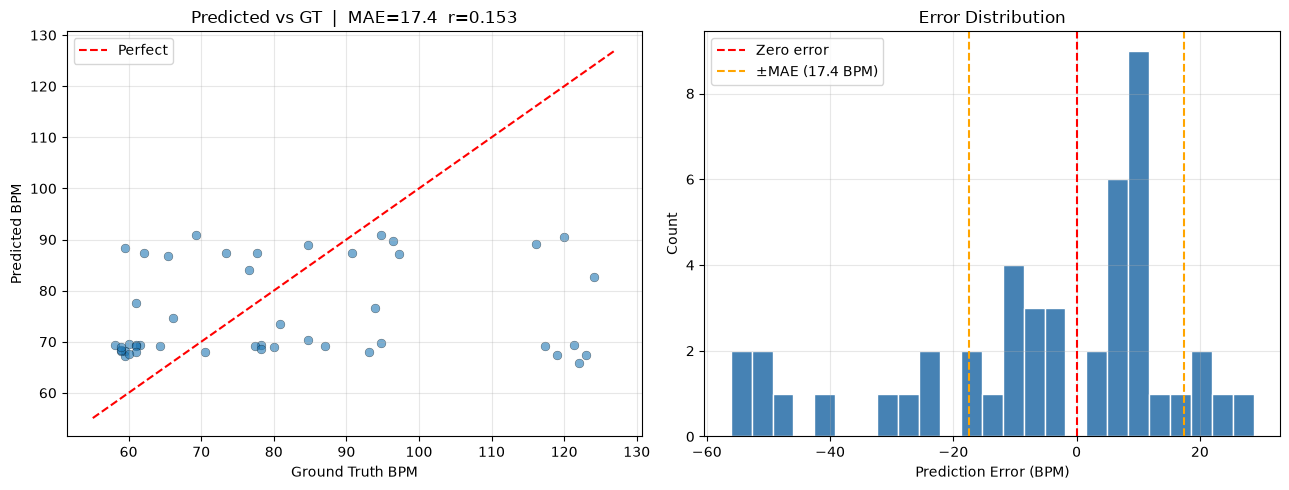

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# scatter: predicted vs ground truth
ax1.scatter(all_targets, all_preds, alpha=0.6, edgecolors='k', linewidths=0.3, s=40)
lim = [min(all_targets.min(), all_preds.min())-3, max(all_targets.max(), all_preds.max())+3]
ax1.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax1.set_xlabel('Ground Truth BPM')
ax1.set_ylabel('Predicted BPM')
ax1.set_title(f'Predicted vs GT  |  MAE={mae:.1f}  r={pearson:.3f}')
ax1.legend()
ax1.grid(alpha=0.3)

# error histogram
errors = all_preds - all_targets
ax2.hist(errors, bins=25, color='steelblue', edgecolor='white')
ax2.axvline(0,    color='red',    linestyle='--', label='Zero error')
ax2.axvline( mae, color='orange', linestyle='--', label=f'±MAE ({mae:.1f} BPM)')
ax2.axvline(-mae, color='orange', linestyle='--')
ax2.set_xlabel('Prediction Error (BPM)')
ax2.set_ylabel('Count')
ax2.set_title('Error Distribution')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "eval_plots.png")
plt.savefig(plot_path, dpi=150)
plt.show()

In [44]:
# final summary
print('=' * 42)
print('           FINAL SUMMARY')
print('=' * 42)
print(f'Data            : NIR.zip (PGM frames)')
print(f'Reference       : pulseOx.mat')
print(f'Total frames    : {len(all_frames)}')
print(f'Train/Val/Test  : {len(train_ds)}/{len(val_ds)}/{len(test_ds)} clips')
print(f'Model params    : {n_params:,}')
print(f'Best epoch      : {best_epoch}')
print(f'Best val MAE    : {best_val_mae:.2f} BPM')
print(f'Test MAE        : {mae:.2f} BPM')
print(f'Test RMSE       : {rmse:.2f} BPM')
print(f'Test Pearson r  : {pearson:.4f}')
print('=' * 42)

           FINAL SUMMARY
Data            : NIR.zip (PGM frames)
Reference       : pulseOx.mat
Total frames    : 10122
Train/Val/Test  : 232/46/46 clips
Model params    : 366,689
Best epoch      : 2
Best val MAE    : 13.87 BPM
Test MAE        : 17.40 BPM
Test RMSE       : 22.85 BPM
Test Pearson r  : 0.1534
